## 07 — ogbg-molpcba Improved: Virtual Node + Extended Training

Addresses the two gaps identified in notebook 06 (GIN test mean AP 0.1492 vs. OGB's official baseline 0.2266): training was cut short at epoch 20 with validation AP still climbing, and the model had no virtual node. This notebook reuses notebook 06's data loading and masked per-task loss unchanged, adds a virtual node to the GIN architecture following OGB's canonical reference implementation, and trains with a much larger epoch budget, an LR scheduler, and proper convergence logging. Closes with an honest before/after comparison against notebook 06 and the official leaderboard.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# BASE_DIR = "/content/drive/MyDrive/molhiv-gnn"

# !pip install torch-geometric ogb rdkit

BASE_DIR = ".."

In [2]:
import pandas as pd
import os
import json
import copy
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_mean_pool, global_add_pool
from ogb.graphproppred import PygGraphPropPredDataset, Evaluator
from ogb.graphproppred.mol_encoder import AtomEncoder

torch.serialization.add_safe_globals([
    torch_geometric.data.data.DataEdgeAttr,
    torch_geometric.data.data.DataTensorAttr,
    torch_geometric.data.storage.GlobalStorage,
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
device

device(type='cuda')

In [3]:
dataset = PygGraphPropPredDataset(name="ogbg-molpcba", root=f"{BASE_DIR}/dataset")
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name="ogbg-molpcba")
num_tasks = dataset.num_tasks

train_loader = DataLoader(dataset[split_idx["train"]], batch_size=512, shuffle=True)
valid_loader = DataLoader(dataset[split_idx["valid"]], batch_size=512, shuffle=False)
test_loader = DataLoader(dataset[split_idx["test"]], batch_size=512, shuffle=False)

len(dataset), {k: len(v) for k, v in split_idx.items()}, num_tasks

(437929, {'train': 350343, 'valid': 43793, 'test': 43793}, 128)

In [4]:
def masked_multitask_loss(pred, target):
    mask = ~torch.isnan(target)
    safe_target = torch.nan_to_num(target, nan=0.0)
    elementwise = F.binary_cross_entropy_with_logits(pred, safe_target, reduction="none")
    elementwise = elementwise * mask.float()
    valid_per_task = mask.sum(dim=0)
    task_has_valid = valid_per_task > 0
    per_task_loss = elementwise.sum(dim=0) / valid_per_task.clamp(min=1)
    return per_task_loss[task_has_valid].mean()

In [5]:
class GIN(nn.Module):
    def __init__(self, hidden_dim, num_layers, dropout, out_dim):
        super().__init__()
        self.atom_encoder = AtomEncoder(hidden_dim)
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINConv(mlp))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.dropout = dropout
        self.out = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index, batch):
        h = self.atom_encoder(x)
        for conv, bn in zip(self.convs, self.bns):
            h = conv(h, edge_index)
            h = bn(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
        h = global_mean_pool(h, batch)
        return self.out(h)


class GINVirtual(nn.Module):
    def __init__(self, hidden_dim, num_layers, dropout, out_dim):
        super().__init__()
        self.num_layers = num_layers
        self.dropout = dropout
        self.atom_encoder = AtomEncoder(hidden_dim)
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINConv(mlp))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.virtualnode_embedding = nn.Embedding(1, hidden_dim)
        nn.init.constant_(self.virtualnode_embedding.weight.data, 0)

        self.mlp_virtualnode_list = nn.ModuleList()
        for _ in range(num_layers - 1):
            self.mlp_virtualnode_list.append(nn.Sequential(
                nn.Linear(hidden_dim, 2 * hidden_dim),
                nn.BatchNorm1d(2 * hidden_dim),
                nn.ReLU(),
                nn.Linear(2 * hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
            ))

        self.out = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index, batch):
        virtualnode_embedding = self.virtualnode_embedding(
            torch.zeros(batch[-1].item() + 1, dtype=torch.long, device=x.device)
        )

        h_list = [self.atom_encoder(x)]
        for layer in range(self.num_layers):
            h_list[layer] = h_list[layer] + virtualnode_embedding[batch]

            h = self.convs[layer](h_list[layer], edge_index)
            h = self.bns[layer](h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            h_list.append(h)

            if layer < self.num_layers - 1:
                virtualnode_embedding_temp = global_add_pool(h_list[layer], batch) + virtualnode_embedding
                virtualnode_embedding = F.dropout(
                    self.mlp_virtualnode_list[layer](virtualnode_embedding_temp),
                    p=self.dropout, training=self.training,
                )

        h_final = h_list[-1]
        h_pooled = global_mean_pool(h_final, batch)
        return self.out(h_pooled)

In [6]:
_plain_gin = GIN(hidden_dim=256, num_layers=5, dropout=0.2, out_dim=num_tasks)
_gin_virtual = GINVirtual(hidden_dim=256, num_layers=5, dropout=0.2, out_dim=num_tasks)

plain_gin_params = sum(p.numel() for p in _plain_gin.parameters())
gin_virtual_params = sum(p.numel() for p in _gin_virtual.parameters())

print("plain GIN (notebook 06) parameter count:", plain_gin_params)
print("GIN + virtual node parameter count:", gin_virtual_params)
print("parameter increase: {:.2f}x".format(gin_virtual_params / plain_gin_params))

del _plain_gin, _gin_virtual

plain GIN (notebook 06) parameter count: 737920
GIN + virtual node parameter count: 1795968
parameter increase: 2.43x


In [7]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = masked_multitask_loss(out, batch.y.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        y_true.append(batch.y.cpu())
        y_pred.append(torch.sigmoid(out).cpu())
    return torch.cat(y_true, dim=0).numpy(), torch.cat(y_pred, dim=0).numpy()


def evaluate(model, loader):
    y_true, y_pred = get_predictions(model, loader)
    return evaluator.eval({"y_true": y_true, "y_pred": y_pred})["ap"]

In [8]:
_sanity_model = GINVirtual(hidden_dim=256, num_layers=5, dropout=0.2, out_dim=num_tasks).to(device)
_sanity_opt = torch.optim.Adam(_sanity_model.parameters(), lr=1e-3)
_sanity_model.train()

for i, sanity_batch in enumerate(train_loader):
    sanity_batch = sanity_batch.to(device)
    _sanity_opt.zero_grad()
    sanity_out = _sanity_model(sanity_batch.x, sanity_batch.edge_index, sanity_batch.batch)
    sanity_loss = masked_multitask_loss(sanity_out, sanity_batch.y.float())
    assert torch.isfinite(sanity_loss), f"non-finite loss at step {i}: {sanity_loss}"
    sanity_loss.backward()
    _sanity_opt.step()
    print(f"sanity step {i}: loss = {sanity_loss.item():.4f}, finite = {torch.isfinite(sanity_loss).item()}")
    if i >= 4:
        break

print("all sanity steps finite, proceeding to timing check")
del _sanity_model, _sanity_opt

sanity step 0: loss = 0.7017, finite = True
sanity step 1: loss = 0.6739, finite = True


sanity step 2: loss = 0.6527, finite = True
sanity step 3: loss = 0.6036, finite = True


sanity step 4: loss = 0.6065, finite = True
all sanity steps finite, proceeding to timing check


In [9]:
_timing_model = GINVirtual(hidden_dim=256, num_layers=5, dropout=0.2, out_dim=num_tasks).to(device)
_timing_opt = torch.optim.Adam(_timing_model.parameters(), lr=1e-3)
_timing_model.train()

t0 = time.time()
n_batches = 0
for i, batch in enumerate(train_loader):
    batch = batch.to(device)
    _timing_opt.zero_grad()
    out = _timing_model(batch.x, batch.edge_index, batch.batch)
    loss = masked_multitask_loss(out, batch.y.float())
    loss.backward()
    _timing_opt.step()
    n_batches += 1
    if i >= 30:
        break
elapsed = time.time() - t0
est_epoch_sec = elapsed / n_batches * len(train_loader)

print(f"GIN+virtual node: {elapsed / n_batches:.3f} sec/batch, estimated {est_epoch_sec:.1f} sec/epoch")
print("plain GIN (notebook 06, measured separately): ~94-100 sec/epoch")
print(f"virtual node training-time overhead: ~{est_epoch_sec / 97 - 1:.0%}")

del _timing_model, _timing_opt

GIN+virtual node: 0.093 sec/batch, estimated 63.6 sec/epoch
plain GIN (notebook 06, measured separately): ~94-100 sec/epoch
virtual node training-time overhead: ~-34%


In [10]:
MAX_EPOCHS = 100
PATIENCE = 15

gin_virtual = GINVirtual(hidden_dim=256, num_layers=5, dropout=0.2, out_dim=num_tasks).to(device)
optimizer = torch.optim.Adam(gin_virtual.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=7)

best_val_ap = 0.0
best_state = None
patience_ctr = 0
history = {"train_loss": [], "val_ap": [], "lr": []}

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_epoch(gin_virtual, train_loader, optimizer)
    val_ap = evaluate(gin_virtual, valid_loader)
    scheduler.step(val_ap)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_ap"].append(val_ap)
    history["lr"].append(current_lr)

    if val_ap > best_val_ap:
        best_val_ap = val_ap
        best_state = copy.deepcopy(gin_virtual.state_dict())
        patience_ctr = 0
    else:
        patience_ctr += 1

    print(f"epoch={epoch:>3}  train_loss={train_loss:.4f}  val_ap={val_ap:.4f}  best_val_ap={best_val_ap:.4f}  lr={current_lr:.2e}")

    if patience_ctr >= PATIENCE:
        print(f"early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

print(f"GIN+virtual node finished with best val AP = {best_val_ap:.4f} after {len(history['val_ap'])} epochs")

epoch=  1  train_loss=0.0802  val_ap=0.0548  best_val_ap=0.0548  lr=1.00e-03


epoch=  2  train_loss=0.0653  val_ap=0.0682  best_val_ap=0.0682  lr=1.00e-03


epoch=  3  train_loss=0.0634  val_ap=0.0882  best_val_ap=0.0882  lr=1.00e-03


epoch=  4  train_loss=0.0613  val_ap=0.0933  best_val_ap=0.0933  lr=1.00e-03


epoch=  5  train_loss=0.0600  val_ap=0.0997  best_val_ap=0.0997  lr=1.00e-03


...

epoch= 96  train_loss=0.0346  val_ap=0.2229  best_val_ap=0.2258  lr=1.00e-03


epoch= 97  train_loss=0.0346  val_ap=0.2271  best_val_ap=0.2271  lr=1.00e-03


epoch= 98  train_loss=0.0340  val_ap=0.2237  best_val_ap=0.2271  lr=1.00e-03


epoch= 99  train_loss=0.0344  val_ap=0.2227  best_val_ap=0.2271  lr=1.00e-03


epoch=100  train_loss=0.0342  val_ap=0.2277  best_val_ap=0.2277  lr=1.00e-03
GIN+virtual node finished with best val AP = 0.2277 after 100 epochs


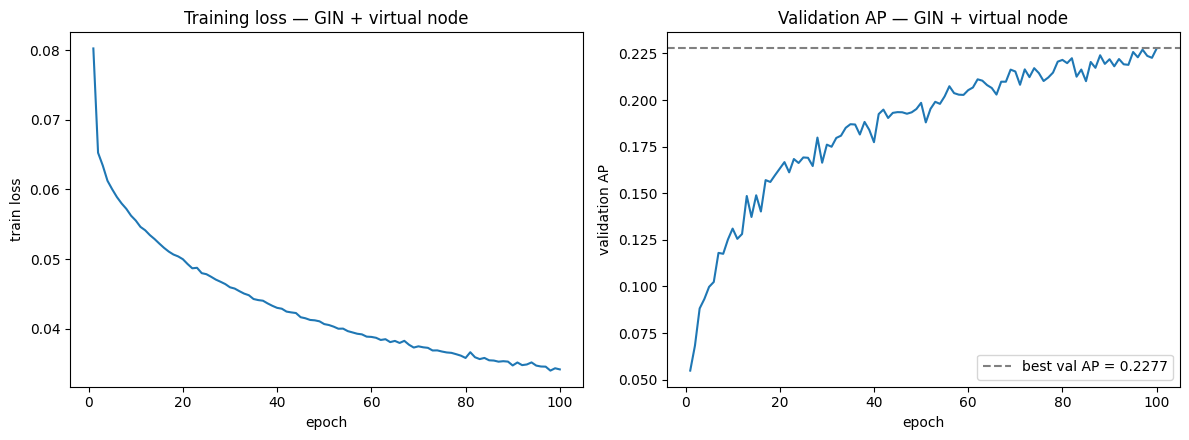

In [11]:
os.makedirs(f"{BASE_DIR}/outputs/figures", exist_ok=True)

epochs_ran = range(1, len(history["val_ap"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_ran, history["train_loss"])
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("train loss")
axes[0].set_title("Training loss — GIN + virtual node")

axes[1].plot(epochs_ran, history["val_ap"])
axes[1].axhline(best_val_ap, linestyle="--", color="gray", label=f"best val AP = {best_val_ap:.4f}")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("validation AP")
axes[1].set_title("Validation AP — GIN + virtual node")
axes[1].legend()

fig.tight_layout()
fig.savefig(f"{BASE_DIR}/outputs/figures/molpcba_improved_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
gin_virtual.load_state_dict(best_state)
improved_y_true, improved_y_pred = get_predictions(gin_virtual, test_loader)
improved_test_ap = evaluator.eval({"y_true": improved_y_true, "y_pred": improved_y_pred})["ap"]

print("GIN + virtual node test mean AP:", improved_test_ap)

GIN + virtual node test mean AP: 0.22043295083569522


In [13]:
with open(f"{BASE_DIR}/outputs/results_molpcba.json") as f:
    results_molpcba_v1 = json.load(f)

comparison = [
    ("Notebook 06 — GIN (no virtual node, 20 epochs)", results_molpcba_v1["gin"]["test_ap"]),
    ("Notebook 06 — GAT (no virtual node, 20 epochs)", results_molpcba_v1["gat"]["test_ap"]),
    ("Notebook 07 — GIN + virtual node (this notebook)", improved_test_ap),
    ("OGB official — GIN, no virtual node", 0.2266),
    ("OGB official — GIN + virtual node", 0.2703),
]

print(f"{'Entry':<48}{'Test mean AP':>14}")
for name, ap in comparison:
    print(f"{name:<48}{ap:>14.4f}")

Entry                                             Test mean AP
Notebook 06 — GIN (no virtual node, 20 epochs)          0.1492
Notebook 06 — GAT (no virtual node, 20 epochs)          0.1179
Notebook 07 — GIN + virtual node (this notebook)        0.2204
OGB official — GIN, no virtual node                     0.2266
OGB official — GIN + virtual node                       0.2703


In [14]:
os.makedirs(f"{BASE_DIR}/models", exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs", exist_ok=True)

torch.save(best_state, f"{BASE_DIR}/models/gin_molpcba_improved.pt")

results_molpcba_improved = {
    "gin_virtual": {
        "config": {"hidden_dim": 256, "num_layers": 5, "dropout": 0.2},
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "epochs_trained": len(history["val_ap"]),
        "val_ap": best_val_ap,
        "test_ap": improved_test_ap,
        "param_count": gin_virtual_params,
        "history": history,
    },
    "before_after_comparison": {name: ap for name, ap in comparison},
}

with open(f"{BASE_DIR}/outputs/results_molpcba_improved.json", "w") as f:
    json.dump(results_molpcba_improved, f, indent=2)

{"improved_test_ap": improved_test_ap, "epochs_trained": len(history["val_ap"])}

{'improved_test_ap': 0.22043295083569522, 'epochs_trained': 100}